DATA PREPROCESSING AND DATASET EXPLORATION

Import Libraries

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset

import torchvision
from torchvision import datasets
from torchvision import transforms

from collections import Counter
from PIL import Image

In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
csv_path = "/content/drive/MyDrive/Visionbench/dataset/fer2013.csv"

Set random seed

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


Exploratory Data Analysis

In [ ]:
df = pd.read_csv(csv_path)
df.head()


,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
df.isnull().sum()

In [ ]:
print(df["emotion"].unique())

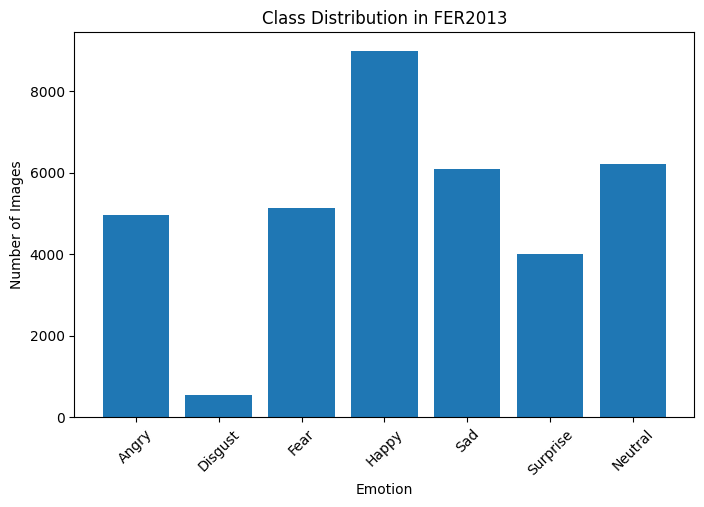

In [ ]:
counts = df["emotion"].value_counts().sort_index()
plt.figure(figsize=(8,5))

emotion_map = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral"
}

plt.bar(
    [emotion_map[i] for i in counts.index],
    counts.values
)

plt.title("Class Distribution in FER2013")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

Dataset summary

In [ ]:
print("="*40)

print("Dataset Summary")

print("="*40)

print("Total Images:", len(df))

print("Training Images:",
      (df["Usage"]=="Training").sum())

print("Public Test:",
      (df["Usage"]=="PublicTest").sum())

print("Private Test:",
      (df["Usage"]=="PrivateTest").sum())

print("="*40)

Dataset Summary
Total Images: 35887
Training Images: 28709
Public Test: 3589
Private Test: 3589


VISUALIZING SAMPLE IMAGES

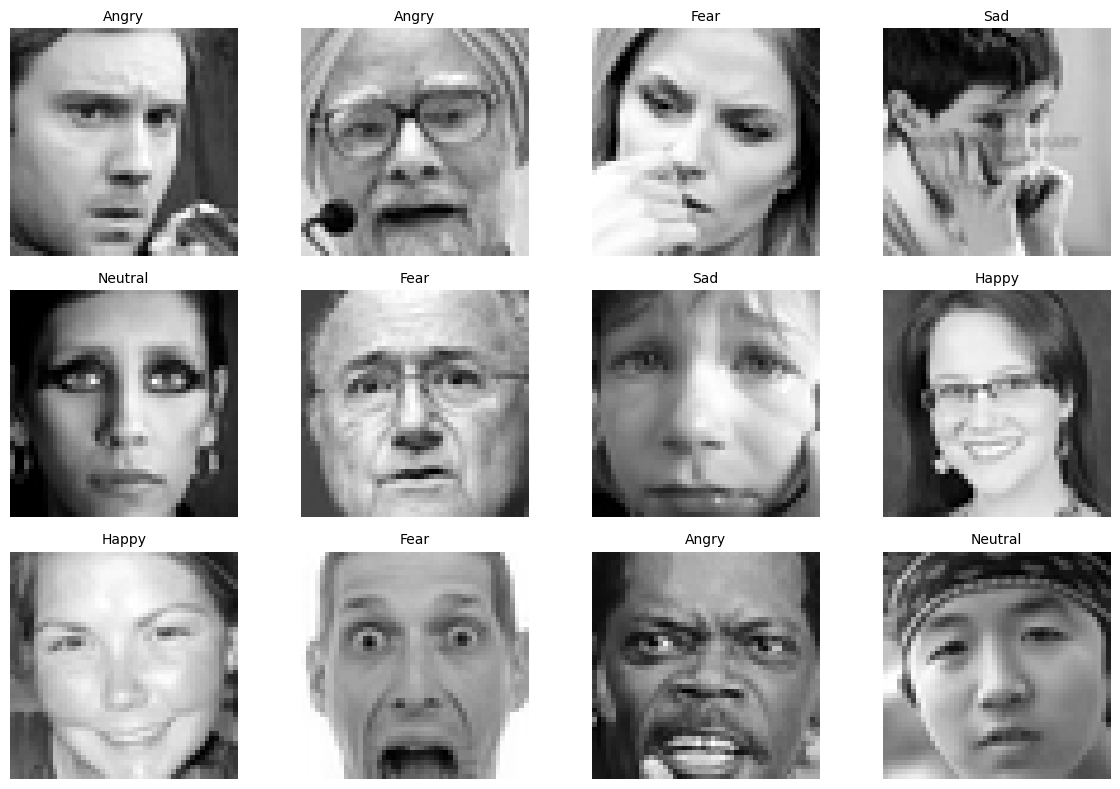

In [ ]:
IMAGE_SIZE= 48
NUM_CLASSES = 7


# Convert pixel string to image
def string_to_image(pixel_string):
    pixels = np.array(pixel_string.split(), dtype=np.uint8)
    image = pixels.reshape(IMAGE_SIZE, IMAGE_SIZE)
    return image

plt.figure(figsize=(12,8))

for i in range(12):
    plt.subplot(3,4,i+1)

    img = string_to_image(df.iloc[i]["pixels"])

    plt.imshow(img, cmap="gray")
    plt.title(emotion_map[df.iloc[i]["emotion"]], fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

IMAGE TRANSFORMATIONS

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485],
        std = [0.229]
    )
])

In [ ]:
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485],
        std = [0.229]
    )
])

DATASET CLASS

In [ ]:

class FER2013Dataset(Dataset):

  def __init__(self, dataframe, transform= None):
    self.dataframe = dataframe
    self.transform = transform

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, idx):
    row = self.dataframe.iloc[idx]

    label = int(row["emotion"])
    pixels = np.array(row["pixels"].split(), dtype=np.uint8)

    image = pixels.reshape(48,48)

    image = Image.fromarray(image)

    image= image.convert("RGB")

    if self.transform:
      image= self.transform(image)

    return image,label




In [ ]:
sample_dataset = FER2013Dataset(df, transform=train_transform)

image, label = sample_dataset[0]

print("Image Shape:", image.shape)
print("Label:", label)
print("Emotion:", emotion_map[label])

Image Shape: torch.Size([3, 224, 224])
Label: 0
Emotion: Angry


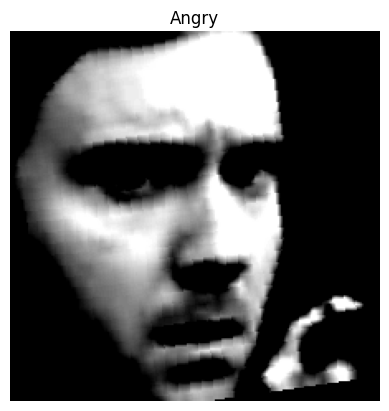

In [ ]:
plt.imshow(image.permute(1, 2, 0))
plt.title(emotion_map[label])
plt.axis("off")
plt.show()

In [ ]:
df["Usage"].value_counts()

train_df = df[df["Usage"]== "Training"].reset_index(drop=True)
val_df = df[df["Usage"]== "PublicTest"].reset_index(drop=True)
test_df = df[df["Usage"] == "PrivateTest"].reset_index(drop=True)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

train_dataset = FER2013Dataset(
    train_df,
    transform=train_transform
)

val_dataset = FER2013Dataset(
    val_df,
    transform=test_transform
)

test_dataset = FER2013Dataset(
    test_df,
    transform=test_transform
)

Training: 28709
Validation: 3589
Testing: 3589


In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

In [ ]:
images, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Batch Shape : torch.Size([32])


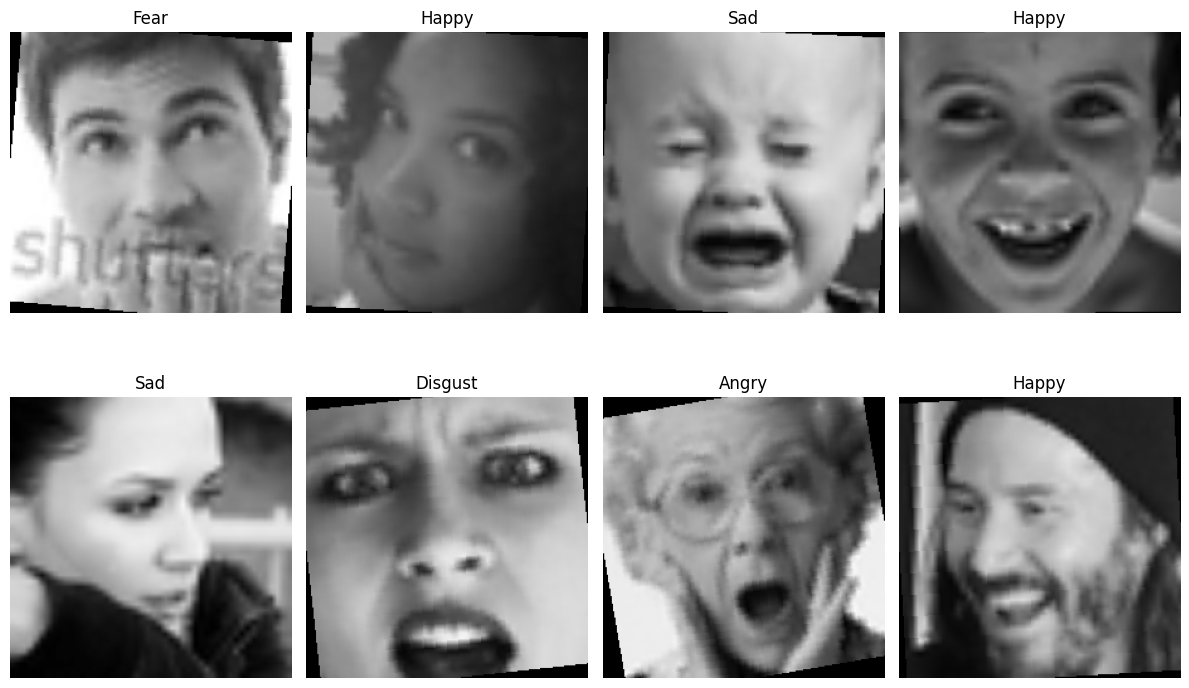

In [ ]:
plt.figure(figsize=(12,8))

for i in range(8):
    plt.subplot(2,4,i+1)

    img = images[i].permute(1,2,0).numpy()

    # Undo normalization for visualization
    img = img * 0.229 + 0.485
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(emotion_map[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()